In [ ]:
import pandas as pd

df = pd.read_csv("dataset/HAM10000/HAM10000_metadata.csv")
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [ ]:
import os
import pandas as pd

df = pd.read_csv("dataset/HAM10000/HAM10000_metadata.csv")

image_dir1 = "dataset/HAM10000/HAM10000_images_part_1/"
image_dir2 = "dataset/HAM10000/HAM10000_images_part_2/"

def get_filepath(image_id):
    filename = image_id + ".jpg"
    if os.path.exists(os.path.join(image_dir1, filename)):
        return os.path.join(image_dir1, filename)
    else:
        return os.path.join(image_dir2, filename)

df["filepath"] = df["image_id"].apply(get_filepath)


(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

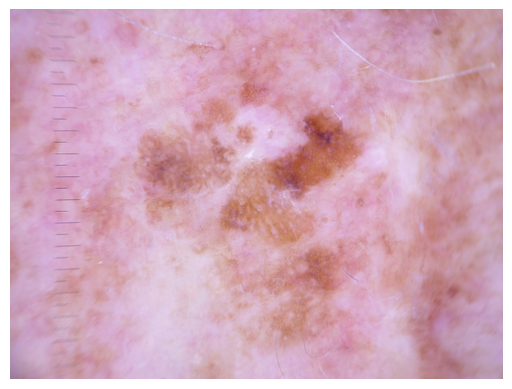

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(df["filepath"].iloc[0])
plt.imshow(img)
plt.axis("off")


In [ ]:
df.isnull().sum()


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
filepath         0
dtype: int64

In [ ]:
df["age"] = df["age"].fillna(df["age"].median())
df["age"].isnull().sum()


np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

df[["dx", "label"]].head()


,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

len(train_df), len(val_df)


(8012, 2003)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224

train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixels
    rotation_range=20,        # light augmentation
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.2,
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)


In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=32
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')   # 7 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/opt/anaconda3/envs/skinscan/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 540ms/step - accuracy: 0.6649 - loss: 1.0352 - val_accuracy: 0.6720 - val_loss: 0.8903
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 143s 567ms/step - accuracy: 0.6700 - loss: 0.9167 - val_accuracy: 0.6915 - val_loss: 0.8626
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 583ms/step - accuracy: 0.6821 - loss: 0.8556 - val_accuracy: 0.6950 - val_loss: 0.8824
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 143s 568ms/step - accuracy: 0.6933 - loss: 0.8206 - val_accuracy: 0.6910 - val_loss: 0.8292
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 140s 557ms/step - accuracy: 0.6993 - loss: 0.8056 - val_accuracy: 0.7189 - val_loss: 0.7982


In [ ]:
print(df.head())
print(df.columns)


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

        dataset                                           filepath  label  
0  vidir_modern  dataset/HAM10000/HAM10000_images_part_1/ISIC_0...      2  
1  vidir_modern  dataset/HAM10000/HAM10000_images_part_1/ISIC_0...      2  
2  vidir_modern  dataset/HAM10000/HAM10000_images_part_1/ISIC_0...      2  
3  vidir_modern  dataset/HAM10000/HAM10000_images_part_1/ISIC_0...      2  
4  vidir_modern  dataset/HAM10000/HAM10000_images_part_2/ISIC_0...      2  
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'dataset', 'filepath', 'label'],
    

In [ ]:
train_generator = train_aug.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_aug.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
# --- Step A: Build EfficientNetB0 (freeze base) ---
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

IMG_SIZE = (224, 224, 3)
NUM_CLASSES = 7  


base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SIZE)

# freeze base for phase 1
base.trainable = False


x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base.input, outputs=outputs)

# compile with a moderately high LR for the newly initialized head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


print("Base trainable:", base.trainable)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base trainable: False


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# --- Step B: Train classifier head only (base frozen) ---

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "phase1_best.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train for 5–10 epochs
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, lr_reduce, checkpoint]
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6541 - loss: 1.2105
Epoch 1: val_loss improved from None to 1.13778, saving model to phase1_best.h5


251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 494ms/step - accuracy: 0.6665 - loss: 1.1652 - val_accuracy: 0.6695 - val_loss: 1.1378 - learning_rate: 0.0010
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6708 - loss: 1.1503
Epoch 2: val_loss improved from 1.13778 to 1.13523, saving model to phase1_best.h5


251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 492ms/step - accuracy: 0.6695 - loss: 1.1510 - val_accuracy: 0.6695 - val_loss: 1.1352 - learning_rate: 0.0010
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6722 - loss: 1.1438
Epoch 3: val_loss did not improve from 1.13523
251/251 ━━━━━━━━━━━━━━━━━━━━ 123s 489ms/step - accuracy: 0.6695 - loss: 1.1488 - val_accuracy: 0.6695 - val_loss: 1.1377 - learning_rate: 0.0010
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6727 - loss: 1.1414
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 4: val_loss did not improve from 1.13523
251/251 ━━━━━━━━━━━━━━━━━━━━ 114s 453ms/step - accuracy: 0.6695 - loss: 1.1487 - val_accuracy: 0.6695 - val_loss: 1.1410 - learning_rate: 0.0010
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.6622 - loss: 1.1583
Epoch 5: val_loss improved from 1.13523 to 1.13443, saving model to phase1_best.h5


251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 471ms/step - accuracy: 0.6695 - loss: 1.1414 - val_accuracy: 0.6695 - val_loss: 1.1344 - learning_rate: 3.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6645 - loss: 1.1565
Epoch 6: val_loss improved from 1.13443 to 1.13053, saving model to phase1_best.h5


251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 483ms/step - accuracy: 0.6695 - loss: 1.1426 - val_accuracy: 0.6695 - val_loss: 1.1305 - learning_rate: 3.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6623 - loss: 1.1581
Epoch 7: val_loss did not improve from 1.13053
251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 483ms/step - accuracy: 0.6695 - loss: 1.1396 - val_accuracy: 0.6695 - val_loss: 1.1338 - learning_rate: 3.0000e-04
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6705 - loss: 1.1381
Epoch 8: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 8: val_loss did not improve from 1.13053
251/251 ━━━━━━━━━━━━━━━━━━━━ 122s 486ms/step - accuracy: 0.6695 - loss: 1.1388 - val_accuracy: 0.6695 - val_loss: 1.1364 - learning_rate: 3.0000e-04
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6603 - loss: 1.1573
Epoch 9: val_loss did not improve from 1.13053
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 505ms/step - accuracy: 0.6695 - loss:

In [ ]:
# --- Step C: Fine-tuning deeper layers of EfficientNet ---

# Unfreeze last 100 layers of EfficientNet
for layer in base.layers[-100:]:
    layer.trainable = True

# Compile with a very low LR for safe fine-tuning
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(1e-5),  # VERY low!
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Trainable layers now:", sum([l.trainable for l in model.layers]))

# Callbacks
fine_tune_ckpt = ModelCheckpoint(
    "phase2_best.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr_reduce_ft = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

# Train phase 2
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[fine_tune_ckpt, early_stop_ft, lr_reduce_ft]
)


In [56]:
model = tf.keras.models.load_model("phase2_best.h5")


In [60]:
model.evaluate(val_gen)


63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 544ms/step - accuracy: 0.6690 - loss: 1.0999


[1.0998979806900024, 0.6689965128898621]

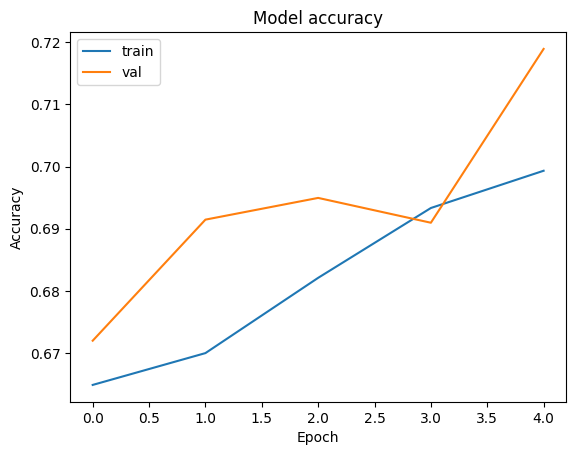

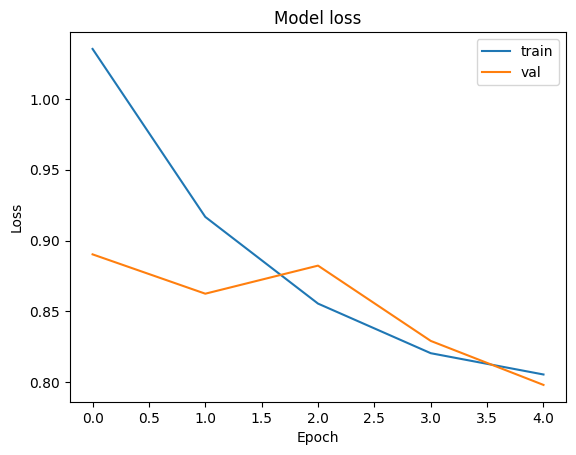

In [61]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])
plt.show()


In [63]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [64]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='phase2_best.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)


In [68]:

base.trainable = True


for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 model ready. Total trainable layers:", len(model.trainable_weights))


Phase 2 model ready. Total trainable layers: 90


In [69]:
model.load_weights("phase1_best.h5")
print("Loaded Phase-1 best weights.")


Loaded Phase-1 best weights.


In [70]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # smaller LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Phase-2 model compiled.")


Phase-2 model compiled.


In [71]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,                       # safe max
    callbacks=[checkpoint, early_stop],
)


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 202s 760ms/step - accuracy: 0.4849 - loss: 1.6657 - val_accuracy: 0.6695 - val_loss: 1.1407
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 187s 746ms/step - accuracy: 0.6695 - loss: 1.1474 - val_accuracy: 0.6695 - val_loss: 1.1600
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 203s 808ms/step - accuracy: 0.6694 - loss: 1.1265 - val_accuracy: 0.6695 - val_loss: 1.1235
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 219s 873ms/step - accuracy: 0.6690 - loss: 1.1159 - val_accuracy: 0.6695 - val_loss: 1.1665
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 214s 851ms/step - accuracy: 0.6685 - loss: 1.0917 - val_accuracy: 0.6670 - val_loss: 1.2467
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 228s 906ms/step - accuracy: 0.6669 - loss: 1.0902 - val_accuracy: 0.6685 - val_loss: 1.2401


In [72]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)


In [74]:
for layer in base.layers[-30:]:
    layer.trainable = True


In [76]:
from tensorflow import keras
from tensorflow.keras import layers


In [77]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])


In [78]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)   # <<< AUGMENTATION ADDED HERE

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 3,987,299 (15.21 MB)

 Non-trainable params: 71,239 (278.28 KB)

In [79]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [80]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop],
)


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.6504 - loss: 1.2299 - val_accuracy: 0.6695 - val_loss: 1.1488
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.6684 - loss: 1.1603 - val_accuracy: 0.6695 - val_loss: 1.1454
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.6691 - loss: 1.1329 - val_accuracy: 0.6695 - val_loss: 1.1235


In [81]:
for layer in base.layers[-150:]:   
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),   
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [82]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 1553s 6s/step - accuracy: 0.6680 - loss: 1.0940 - val_accuracy: 0.6695 - val_loss: 1.1515
Epoch 2/20
 14/251 ━━━━━━━━━━━━━━━━━━━━ 25:10 6s/step - accuracy: 0.6526 - loss: 1.0513

KeyboardInterrupt: 